# Time-to-Event Prediction with Survival Analysis

## Goal

This notebook applies supervised survival analysis to predict the timing of an event while accounting for right-censored observations.

The dataset follows individuals for up to 52 weeks and records:

- how long each individual was observed
- whether the event occurred during observation
- several characteristics available at the start of follow-up

## Why ordinary classification is insufficient

A binary classifier would reduce the outcome to:

- event occurred
- event did not occur

However, an individual recorded without an event may simply have reached the end of follow-up before the event could be observed.

Survival analysis retains both pieces of information:

- `duration`: time until event or censoring
- `event`: whether the event was actually observed

## Models

### Kaplan–Meier estimator

Estimates population-level event-free survival without individual predictors.

### Cox proportional-hazards model

Predicts relative event risk without assuming a particular baseline survival distribution.

### Weibull accelerated-failure-time model

Directly models whether predictors are associated with longer or shorter survival time.

## Evaluation

- Test concordance index
- Bootstrap confidence intervals
- Survival-probability calibration
- Kaplan–Meier curves
- Hazard ratios
- Time ratios
- Individual predicted survival curves
- Proportional-hazards assumption checks

## Important ethical note

This is a methodological survival-analysis exercise.

The dataset concerns a criminal-justice outcome and must not be treated as a suitable decision system. Race is excluded from predictive modelling, and all relationships are interpreted as associations rather than causal effects.

In [ ]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from lifelines import (
    KaplanMeierFitter,
    CoxPHFitter,
    WeibullAFTFitter
)

from lifelines.datasets import load_rossi

from lifelines.statistics import (
    logrank_test
)

from lifelines.utils import (
    concordance_index
)

from lifelines.calibration import (
    survival_probability_calibration
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.25
CALIBRATION_WEEK = 26


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)


set_seed(RANDOM_STATE)

print("Random state:", RANDOM_STATE)

Random state: 42


In [4]:
raw_df = load_rossi()

print("Original shape:", raw_df.shape)

raw_df.head()

Original shape: (432, 9)


,week,arrest,fin,age,race,wexp,mar,paro,prio
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3


In [5]:
column_name_mapping = {
    "week": "duration_weeks",
    "arrest": "event_observed",
    "fin": "financial_aid",
    "age": "age",
    "race": "race_indicator",
    "wexp": "work_experience",
    "mar": "married",
    "paro": "parole",
    "prio": "prior_convictions"
}

df = raw_df.rename(
    columns=column_name_mapping
).copy()

df["event_observed"] = (
    df["event_observed"].astype(int)
)

df.head()

,duration_weeks,event_observed,financial_aid,age,race_indicator,work_experience,married,parole,prior_convictions
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3


In [6]:
column_description_df = pd.DataFrame({
    "column": [
        "duration_weeks",
        "event_observed",
        "financial_aid",
        "age",
        "race_indicator",
        "work_experience",
        "married",
        "parole",
        "prior_convictions"
    ],
    "description": [
        "Observed duration in weeks",
        "1 if the event occurred, 0 if censored",
        "Binary financial-aid indicator",
        "Age at the beginning of observation",
        "Dataset race indicator; excluded from modelling",
        "Binary work-experience indicator",
        "Binary marital-status indicator",
        "Binary parole indicator",
        "Number of prior convictions"
    ]
})

column_description_df

,column,description
0,duration_weeks,Observed duration in weeks
1,event_observed,"1 if the event occurred, 0 if censored"
2,financial_aid,Binary financial-aid indicator
3,age,Age at the beginning of observation
4,race_indicator,Dataset race indicator; excluded from modelling
5,work_experience,Binary work-experience indicator
6,married,Binary marital-status indicator
7,parole,Binary parole indicator
8,prior_convictions,Number of prior convictions


In [7]:
analysis_df = df.drop(
    columns=["race_indicator"]
).copy()

feature_columns = [
    "financial_aid",
    "age",
    "work_experience",
    "married",
    "parole",
    "prior_convictions"
]

duration_column = "duration_weeks"
event_column = "event_observed"

analysis_df.head()

,duration_weeks,event_observed,financial_aid,age,work_experience,married,parole,prior_convictions
0,20,1,0,27,0,0,1,3
1,17,1,0,18,0,0,1,8
2,25,1,0,19,1,0,1,13
3,52,0,1,23,1,1,1,1
4,52,0,0,19,1,0,1,3


## Dataset and ethics note

The dataset contained 432 observations and eight columns after removing the race indicator.

Each observation included:

- a follow-up duration in weeks
- an event indicator
- six predictors used for modelling

The event represented an arrest observed during the 52-week follow-up period.

The race indicator was deliberately excluded from predictive modelling. However, removing one protected attribute does not guarantee fairness. Other variables may still reflect historical inequalities or act as proxies for protected characteristics.

The results should therefore be treated only as a methodological survival-analysis exercise. They should not be used for sentencing, parole, policing, or individual criminal-justice decisions.

In [9]:
number_of_observations = len(
    analysis_df
)

number_of_events = int(
    analysis_df[event_column].sum()
)

number_censored = (
    number_of_observations
    - number_of_events
)

event_rate = (
    number_of_events
    / number_of_observations
)

dataset_summary_df = pd.DataFrame({
    "metric": [
        "Observations",
        "Observed events",
        "Censored observations",
        "Event rate",
        "Maximum follow-up",
        "Median observed duration"
    ],
    "value": [
        number_of_observations,
        number_of_events,
        number_censored,
        event_rate,
        analysis_df[
            duration_column
        ].max(),
        analysis_df[
            duration_column
        ].median()
    ]
})

dataset_summary_df

,metric,value
0,Observations,432.000000
1,Observed events,114.000000
2,Censored observations,318.000000
3,Event rate,0.263889
4,Maximum follow-up,52.000000
5,Median observed duration,52.000000


In [10]:
analysis_df[
    feature_columns
    + [
        duration_column,
        event_column
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
financial_aid,432.0,0.500000,0.500580,0.0,0.0,0.5,1.0,1.0
age,432.0,24.597222,6.113375,17.0,20.0,23.0,27.0,44.0
work_experience,432.0,0.571759,0.495398,0.0,0.0,1.0,1.0,1.0
married,432.0,0.122685,0.328456,0.0,0.0,0.0,0.0,1.0
parole,432.0,0.618056,0.486426,0.0,0.0,1.0,1.0,1.0
prior_convictions,432.0,2.983796,2.896068,0.0,1.0,2.0,4.0,18.0
duration_weeks,432.0,45.854167,12.662293,1.0,50.0,52.0,52.0,52.0
event_observed,432.0,0.263889,0.441251,0.0,0.0,0.0,1.0,1.0


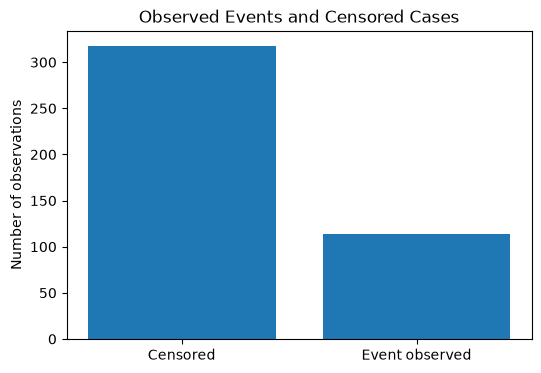

In [11]:
event_status_counts = (
    analysis_df[event_column]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6, 4))

plt.bar(
    ["Censored", "Event observed"],
    [
        event_status_counts.get(0, 0),
        event_status_counts.get(1, 0)
    ]
)

plt.title("Observed Events and Censored Cases")
plt.ylabel("Number of observations")
plt.show()

## Censoring 

The dataset contained:

- 432 total observations
- 114 observed events
- 318 censored observations
- Event rate: 26.39%
- Censored proportion: 73.61%
- Maximum follow-up: 52 weeks
- Median observed duration: 52 weeks

Most individuals reached the end of the observation period without a recorded event.

A censored observation does not mean that the person could never experience the event. It means only that the event was not observed before follow-up ended.

Treating all 318 censored cases as permanent non-events would discard information about how long they remained event-free and would incorrectly imply that their final outcome was known.

In [12]:
kaplan_meier = KaplanMeierFitter()

kaplan_meier.fit(
    durations=analysis_df[
        duration_column
    ],
    event_observed=analysis_df[
        event_column
    ],
    label="Overall event-free survival"
)

<lifelines.KaplanMeierFitter:"Overall event-free survival", fitted with 432 total observations, 318 right-censored observations>

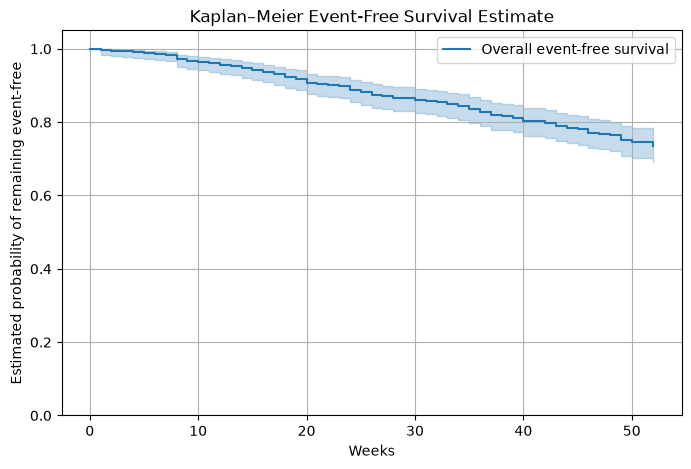

In [13]:
plt.figure(figsize=(8, 5))

kaplan_meier.plot_survival_function(
    ci_show=True
)

plt.title("Kaplan–Meier Event-Free Survival Estimate")
plt.xlabel("Weeks")
plt.ylabel("Estimated probability of remaining event-free")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

In [14]:
survival_checkpoints = pd.DataFrame({
    "week": [13, 26, 39, 52],
    "estimated_event_free_probability": [
        float(
            kaplan_meier.predict(week)
        )
        for week in [13, 26, 39, 52]
    ]
})

survival_checkpoints[
    "estimated_event_probability"
] = (
    1
    - survival_checkpoints[
        "estimated_event_free_probability"
    ]
)

survival_checkpoints

,week,estimated_event_free_probability,estimated_event_probability
0,13,0.953704,0.046296
1,26,0.875000,0.125000
2,39,0.812500,0.187500
3,52,0.736111,0.263889


## Overall survival 

The Kaplan–Meier estimator produced the following population-level event-free survival probabilities:

| Week | Event-free probability | Estimated event probability |
|---:|---:|---:|
| 13 | 0.9537 | 0.0463 |
| 26 | 0.8750 | 0.1250 |
| 39 | 0.8125 | 0.1875 |
| 52 | 0.7361 | 0.2639 |

The estimated probability of remaining event-free declined steadily throughout follow-up.

At Week 26, approximately 87.5% of the population was estimated to remain event-free. By Week 52, this had fallen to approximately 73.61%.

The Week 52 event probability matched the overall observed event rate because the dataset's follow-up ended at 52 weeks.

This curve represents the average survival experience and does not yet adjust for individual characteristics.

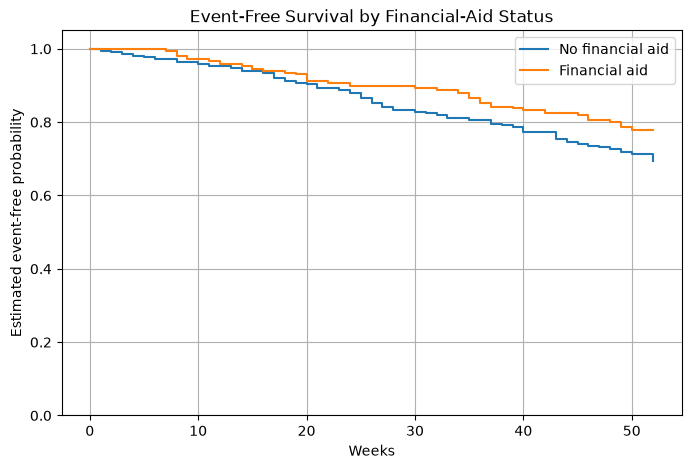

In [15]:
plt.figure(figsize=(8, 5))

for group_value, group_name in [
    (0, "No financial aid"),
    (1, "Financial aid")
]:
    group_mask = (
        analysis_df["financial_aid"]
        == group_value
    )

    group_km = KaplanMeierFitter()

    group_km.fit(
        durations=analysis_df.loc[
            group_mask,
            duration_column
        ],
        event_observed=analysis_df.loc[
            group_mask,
            event_column
        ],
        label=group_name
    )

    group_km.plot_survival_function(
        ci_show=False
    )

plt.title("Event-Free Survival by Financial-Aid Status")
plt.xlabel("Weeks")
plt.ylabel("Estimated event-free probability")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

In [16]:
financial_aid_group_0 = analysis_df[
    analysis_df["financial_aid"] == 0
]

financial_aid_group_1 = analysis_df[
    analysis_df["financial_aid"] == 1
]

financial_aid_logrank = logrank_test(
    financial_aid_group_0[
        duration_column
    ],
    financial_aid_group_1[
        duration_column
    ],
    event_observed_A=
        financial_aid_group_0[
            event_column
        ],
    event_observed_B=
        financial_aid_group_1[
            event_column
        ]
)

print(
    "Financial-aid log-rank p-value:",
    financial_aid_logrank.p_value
)

Financial-aid log-rank p-value: 0.050116117409005755


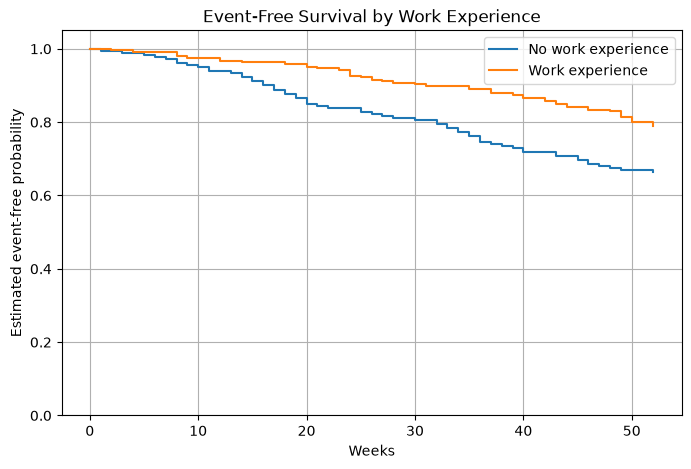

In [17]:
plt.figure(figsize=(8, 5))

for group_value, group_name in [
    (0, "No work experience"),
    (1, "Work experience")
]:
    group_mask = (
        analysis_df["work_experience"]
        == group_value
    )

    group_km = KaplanMeierFitter()

    group_km.fit(
        durations=analysis_df.loc[
            group_mask,
            duration_column
        ],
        event_observed=analysis_df.loc[
            group_mask,
            event_column
        ],
        label=group_name
    )

    group_km.plot_survival_function(
        ci_show=False
    )

plt.title("Event-Free Survival by Work Experience")
plt.xlabel("Weeks")
plt.ylabel("Estimated event-free probability")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

In [18]:
work_group_0 = analysis_df[
    analysis_df["work_experience"] == 0
]

work_group_1 = analysis_df[
    analysis_df["work_experience"] == 1
]

work_experience_logrank = logrank_test(
    work_group_0[duration_column],
    work_group_1[duration_column],
    event_observed_A=
        work_group_0[event_column],
    event_observed_B=
        work_group_1[event_column]
)

print(
    "Work-experience log-rank p-value:",
    work_experience_logrank.p_value
)

Work-experience log-rank p-value: 0.0016434568540925982


## Group survival-curves 

### Financial aid

Individuals receiving financial aid generally had higher estimated event-free survival than those not receiving aid.

The difference became clearer during the later part of follow-up. At the end of the observation period, the financial-aid group remained near 0.78 event-free survival, while the no-aid group was near 0.70.

The log-rank test produced:

`p = 0.0501`

This result was extremely close to the conventional 0.05 threshold but slightly above it. It should therefore be described as borderline evidence rather than a clearly statistically significant difference.

### Work experience

Individuals with prior work experience showed consistently higher event-free survival than those without work experience.

By the end of follow-up, event-free survival was approximately:

- 0.79 for individuals with work experience
- 0.66 for individuals without work experience

The log-rank test produced:

`p = 0.00164`

This provided much stronger evidence that the two unadjusted survival curves differed.

These comparisons were unadjusted and did not account for age, prior convictions, marital status, or the other predictors.

In [19]:
train_df, test_df = train_test_split(
    analysis_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=analysis_df[event_column]
)

train_df = train_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)

split_summary_df = pd.DataFrame({
    "split": ["Training", "Test"],
    "observations": [
        len(train_df),
        len(test_df)
    ],
    "events": [
        int(train_df[event_column].sum()),
        int(test_df[event_column].sum())
    ],
    "event_rate": [
        train_df[event_column].mean(),
        test_df[event_column].mean()
    ]
})

split_summary_df

,split,observations,events,event_rate
0,Training,324,85,0.262346
1,Test,108,29,0.268519


## Data-split 

The stratified split produced:

| Split | Observations | Events | Event rate |
|---|---:|---:|---:|
| Training | 324 | 85 | 0.2623 |
| Test | 108 | 29 | 0.2685 |

Stratification preserved almost identical event proportions in the training and test sets.

All coefficient estimation and model fitting used only the 324 training observations. The 108 test observations remained separate for final discrimination and calibration evaluation.

The test set contained only 29 observed events, so its performance estimates carry considerable uncertainty.

In [20]:
constant_survival_scores = np.zeros(
    len(test_df)
)

constant_c_index = concordance_index(
    test_df[duration_column],
    constant_survival_scores,
    test_df[event_column]
)

print(
    "Constant-risk test C-index:",
    round(constant_c_index, 4)
)

Constant-risk test C-index: 0.5


In [21]:
age_only_columns = [
    duration_column,
    event_column,
    "age"
]

age_only_cox = CoxPHFitter(
    penalizer=0.01
)

age_only_cox.fit(
    train_df[age_only_columns],
    duration_col=duration_column,
    event_col=event_column
)

age_only_risk = (
    age_only_cox.predict_partial_hazard(
        test_df[["age"]]
    )
    .to_numpy()
    .ravel()
)

age_only_c_index = concordance_index(
    test_df[duration_column],
    -age_only_risk,
    test_df[event_column]
)

print(
    "Age-only Cox test C-index:",
    round(age_only_c_index, 4)
)

Age-only Cox test C-index: 0.6821


## Baseline 

The constant-risk baseline achieved a test concordance index of:

`0.5000`

Because every individual received the same score, the baseline had no ability to rank which comparable individual would experience the event sooner.

The age-only Cox model achieved:

`0.6821`

Age alone therefore provided meaningful risk-ranking information and substantially outperformed the no-ranking reference.

This simple baseline became particularly important because it ultimately achieved a higher test C-index than either full multivariable model.

In [52]:
cox_model = CoxPHFitter(
    penalizer=0.01
)

cox_model.fit(
    train_df,
    duration_col=duration_column,
    event_col=event_column
)

cox_model.print_summary()

AttributeError: The '.style' accessor requires jinja2

<lifelines.CoxPHFitter: fitted with 324 total observations, 239 right-censored observations>
             duration col = 'duration_weeks'
                event col = 'event_observed'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 324
number of events observed = 85
   partial log-likelihood = -467.03
         time fit was run = 2026-07-21 05:25:33 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
financial_aid     -0.31      0.73      0.22           -0.73            0.11                0.48                1.12
age               -0.04      0.96      0.02           -0.09            0.00                0.92                1.00
work_experience   -0.13      0.88      0.24           -0.59            0.34                0.55                1.40
married           -0.63      0.53      0.45           -1.51            0.24                0.22                1.28
parole            -0.01      0.99      0.22           -0.44            0.43                0.65                1.53
prior_convictions  0.10      1.11      0.03            0.04            0.16                1.04                1.17

                   cmp to     z      p  -log2(p)
covariate                                       
financial_aid        0.00 -1.43   0.15      2.72
age                  0.00 -1.89   0.06      4.09
work_experience      0.00 -0.53   0.59      0.75
married              0.00 -1.42   0.16      2.68
parole               0.00 -0.03   0.98      0.03
prior_convictions    0.00  3.39 <0.005     10.46
---
Concordance = 0.65
Partial AIC = 946.06
log-likelihood ratio test = 24.42 on 6 df
-log2(p) of ll-ratio test = 11.16

In [23]:
cox_summary_df = (
    cox_model.summary[
        [
            "coef",
            "exp(coef)",
            "se(coef)",
            "p",
            "coef lower 95%",
            "coef upper 95%"
        ]
    ]
    .rename(columns={
        "coef": "log_hazard_coefficient",
        "exp(coef)": "hazard_ratio",
        "se(coef)": "standard_error",
        "p": "p_value",
        "coef lower 95%":
            "coefficient_lower_95",
        "coef upper 95%":
            "coefficient_upper_95"
    })
    .sort_values(
        "hazard_ratio",
        ascending=False
    )
)

cox_summary_df

,log_hazard_coefficient,hazard_ratio,standard_error,p_value,coefficient_lower_95,coefficient_upper_95
covariate,,,,,,
prior_convictions,0.102094,1.107487,0.030150,0.000709,0.043000,0.161187
parole,-0.005557,0.994458,0.220486,0.979892,-0.437703,0.426588
age,-0.043119,0.957797,0.022816,0.058776,-0.087838,0.001599
work_experience,-0.127304,0.880466,0.238246,0.593108,-0.594257,0.339650
financial_aid,-0.309316,0.733949,0.215824,0.151804,-0.732324,0.113691
married,-0.634457,0.530224,0.447760,0.156496,-1.512051,0.243138


## Cox coefficient 

The fitted Cox model produced the following adjusted hazard ratios:

| Predictor | Hazard ratio | p-value |
|---|---:|---:|
| Prior convictions | 1.1075 | 0.0007 |
| Parole | 0.9945 | 0.9799 |
| Age | 0.9578 | 0.0588 |
| Work experience | 0.8805 | 0.5931 |
| Financial aid | 0.7339 | 0.1518 |
| Married | 0.5302 | 0.1565 |

### Prior convictions

Prior convictions had the strongest positive association with hazard.

Its hazard ratio of 1.1075 means that each additional prior conviction was associated with approximately a 10.75% increase in instantaneous event risk, holding the other included variables constant.

This was the only predictor with clear conventional statistical evidence:

`p = 0.0007`

### Age

Age had a hazard ratio of 0.9578.

Each additional year of age was associated with approximately a 4.22% reduction in hazard. However, its p-value of 0.0588 was slightly above 0.05, so the evidence was borderline.

### Married status

Married status had the smallest estimated hazard ratio, 0.5302, suggesting substantially lower hazard. However, the estimate was statistically uncertain, with a wide confidence interval and p-value of 0.1565.

### Other predictors

Financial aid and work experience were associated with lower estimated hazard, but neither had strong adjusted statistical evidence.

Parole had a hazard ratio almost exactly equal to one, indicating almost no estimated adjusted relationship.

All coefficients describe associations rather than causal effects.

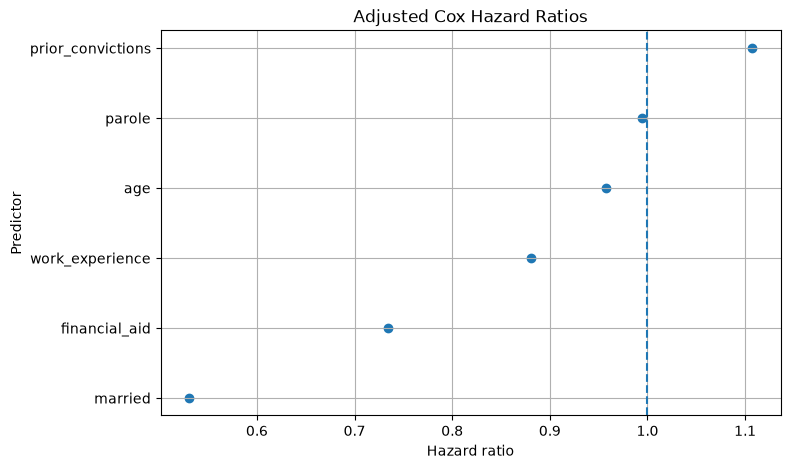

In [24]:
cox_plot_df = (
    cox_summary_df
    .sort_values(
        "hazard_ratio"
    )
)

plt.figure(figsize=(8, 5))

plt.scatter(
    cox_plot_df["hazard_ratio"],
    cox_plot_df.index
)

plt.axvline(
    1.0,
    linestyle="--"
)

plt.title("Adjusted Cox Hazard Ratios")
plt.xlabel("Hazard ratio")
plt.ylabel("Predictor")
plt.grid(True)
plt.show()

## Hazard-ratio plot 

Prior convictions was the only predictor with a hazard ratio clearly above one:

`Hazard ratio = 1.1075`

Married status had the smallest estimated hazard ratio:

`Hazard ratio = 0.5302`

Financial aid and work experience also had hazard ratios below one, but their coefficient uncertainty was substantial.

Parole was almost exactly centred on the no-association value of one.

The plot demonstrates that effect size and statistical certainty are different. Married status had the largest estimated protective association, but the available sample did not estimate that relationship precisely enough to rule out a much weaker or absent association.

In [50]:
weibull_model = WeibullAFTFitter(
    penalizer=0.01
)

weibull_model.fit(
    train_df,
    duration_col=duration_column,
    event_col=event_column
)

weibull_model.print_summary()

AttributeError: The '.style' accessor requires jinja2

<lifelines.WeibullAFTFitter: fitted with 324 total observations, 239 right-censored observations>
             duration col = 'duration_weeks'
                event col = 'event_observed'
                penalizer = 0.01
   number of observations = 324
number of events observed = 85
           log-likelihood = -506.98
         time fit was run = 2026-07-21 05:25:06 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                          
lambda_ age                0.03      1.03      0.02           -0.00            0.06                1.00                1.06
        financial_aid      0.22      1.25      0.15           -0.08            0.52                0.93                1.69
        married            0.46      1.59      0.32           -0.17            1.09                0.84                2.99
        parole            -0.00      1.00      0.16           -0.30            0.30                0.74                1.35
        prior_convictions -0.07      0.93      0.02           -0.12           -0.03                0.89                0.97
        work_experience    0.08      1.09      0.17           -0.25            0.42                0.78                1.51
        Intercept          4.10     60.61      0.40            3.32            4.89               27.72              132.52
rho_    Intercept          0.36      1.44      0.10            0.16            0.56                1.18                1.75

                           cmp to     z      p  -log2(p)
param   covariate                                       
lambda_ age                  0.00  1.86   0.06      3.99
        financial_aid        0.00  1.46   0.15      2.78
        married              0.00  1.43   0.15      2.70
        parole               0.00 -0.00   1.00      0.00
        prior_convictions    0.00 -3.35 <0.005     10.28
        work_experience      0.00  0.50   0.62      0.69
        Intercept            0.00 10.28 <0.005     79.97
rho_    Intercept            0.00  3.57 <0.005     11.43
---
Concordance = 0.65
AIC = 1029.95
log-likelihood ratio test = 24.73 on 6 df
-log2(p) of ll-ratio test = 11.35

In [26]:
weibull_summary_df = (
    weibull_model.summary
    .reset_index()
)

weibull_covariate_df = (
    weibull_summary_df[
        weibull_summary_df["param"]
        == "lambda_"
    ]
    .copy()
)

weibull_covariate_df = (
    weibull_covariate_df[
        weibull_covariate_df[
            "covariate"
        ] != "Intercept"
    ]
    [
        [
            "covariate",
            "coef",
            "exp(coef)",
            "p"
        ]
    ]
    .rename(columns={
        "coef":
            "log_time_coefficient",
        "exp(coef)":
            "time_ratio",
        "p":
            "p_value"
    })
    .sort_values(
        "time_ratio",
        ascending=False
    )
)

weibull_covariate_df

,covariate,log_time_coefficient,time_ratio,p_value
2,married,0.460886,1.585477,0.153391
1,financial_aid,0.222894,1.249688,0.145400
5,work_experience,0.084222,1.087871,0.617876
0,age,0.030648,1.031123,0.063027
3,parole,-0.000569,0.999431,0.997075
4,prior_convictions,-0.073458,0.929175,0.000806


## Weibull AFT model 

The Weibull accelerated-failure-time model produced the following time ratios:

| Predictor | Time ratio | p-value |
|---|---:|---:|
| Married | 1.5855 | 0.1534 |
| Financial aid | 1.2497 | 0.1454 |
| Work experience | 1.0879 | 0.6179 |
| Age | 1.0311 | 0.0630 |
| Parole | 0.9994 | 0.9971 |
| Prior convictions | 0.9292 | 0.0008 |

In an AFT model:

- a time ratio above one is associated with longer event-free duration
- a time ratio below one is associated with shorter event-free duration

Married status had the largest estimated longer-survival association. Its time ratio of 1.5855 suggested approximately 58.55% longer event-free duration, but this estimate was statistically uncertain.

Prior convictions had the strongest shorter-survival association. Each additional prior conviction was associated with multiplying expected event-free time by approximately 0.929, corresponding to roughly 7.1% shorter duration.

Prior convictions was again the only predictor with clear conventional statistical evidence.

The directions were consistent with the Cox model: variables associated with higher hazard generally had time ratios below one.

In [27]:
cox_test_risk = (
    cox_model.predict_partial_hazard(
        test_df[feature_columns]
    )
    .to_numpy()
    .ravel()
)

cox_test_survival_score = (
    -cox_test_risk
)

cox_test_c_index = concordance_index(
    test_df[duration_column],
    cox_test_survival_score,
    test_df[event_column]
)

In [28]:
weibull_predicted_median = (
    weibull_model.predict_median(
        test_df[feature_columns]
    )
    .to_numpy()
    .ravel()
)

weibull_test_c_index = (
    concordance_index(
        test_df[duration_column],
        weibull_predicted_median,
        test_df[event_column]
    )
)

In [29]:
model_comparison_df = pd.DataFrame([
    {
        "model":
            "Constant-risk baseline",
        "test_c_index":
            constant_c_index
    },
    {
        "model":
            "Age-only Cox",
        "test_c_index":
            age_only_c_index
    },
    {
        "model":
            "Full Cox PH",
        "test_c_index":
            cox_test_c_index
    },
    {
        "model":
            "Weibull AFT",
        "test_c_index":
            weibull_test_c_index
    }
]).sort_values(
    "test_c_index",
    ascending=False
)

model_comparison_df

,model,test_c_index
1,Age-only Cox,0.682071
3,Weibull AFT,0.618040
2,Full Cox PH,0.617669
0,Constant-risk baseline,0.500000


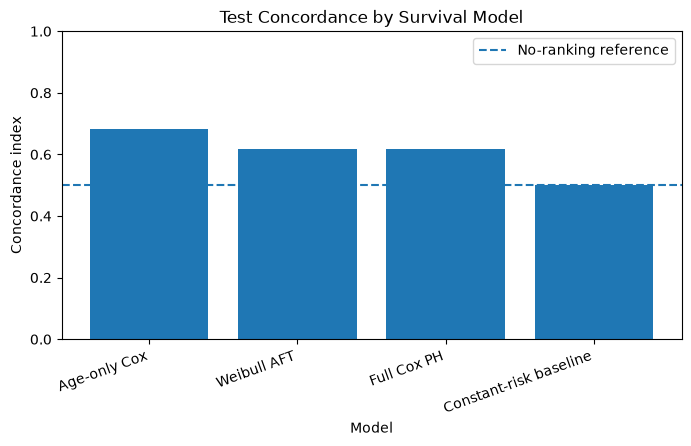

In [30]:
plt.figure(figsize=(8, 4))

plt.bar(
    model_comparison_df["model"],
    model_comparison_df[
        "test_c_index"
    ]
)

plt.axhline(
    0.50,
    linestyle="--",
    label="No-ranking reference"
)

plt.title("Test Concordance by Survival Model")
plt.xlabel("Model")
plt.ylabel("Concordance index")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.show()

## Model-discrimination 

Test concordance results were:

| Model | Test C-index |
|---|---:|
| Age-only Cox | 0.6821 |
| Weibull AFT | 0.6180 |
| Full Cox PH | 0.6177 |
| Constant-risk baseline | 0.5000 |

The age-only Cox model achieved the strongest test discrimination.

The complete feature set did not improve ranking over age alone. Instead, the full Cox C-index was approximately 0.064 lower.

Possible explanations include:

- the small number of training events
- additional noisy predictors
- coefficient-estimation variance
- proportional-hazards violations
- overfitting relative to the simple age-only model

The full Cox and Weibull models performed almost identically, differing by only about 0.0004.

Both full models ranked cases better than chance, but their discrimination was only moderate. The result also demonstrates that adding predictors does not automatically improve out-of-sample performance.

In [31]:
def bootstrap_concordance_interval(
    durations,
    events,
    predicted_survival_scores,
    repetitions=1_000,
    confidence_level=0.95,
    seed=42
):
    durations = np.asarray(durations)
    events = np.asarray(events)

    predicted_survival_scores = (
        np.asarray(
            predicted_survival_scores
        )
    )

    rng = np.random.default_rng(seed)

    bootstrap_scores = []

    number_of_rows = len(durations)

    for _ in range(repetitions):
        sampled_indices = rng.integers(
            0,
            number_of_rows,
            size=number_of_rows
        )

        try:
            score = concordance_index(
                durations[sampled_indices],
                predicted_survival_scores[
                    sampled_indices
                ],
                events[sampled_indices]
            )

            bootstrap_scores.append(
                score
            )

        except ZeroDivisionError:
            continue

    bootstrap_scores = np.asarray(
        bootstrap_scores
    )

    alpha = (
        1 - confidence_level
    ) / 2

    return {
        "mean":
            bootstrap_scores.mean(),
        "lower":
            np.quantile(
                bootstrap_scores,
                alpha
            ),
        "upper":
            np.quantile(
                bootstrap_scores,
                1 - alpha
            ),
        "successful_repetitions":
            len(bootstrap_scores),
        "scores":
            bootstrap_scores
    }

In [32]:
cox_bootstrap = (
    bootstrap_concordance_interval(
        durations=test_df[
            duration_column
        ],
        events=test_df[event_column],
        predicted_survival_scores=
            cox_test_survival_score,
        seed=RANDOM_STATE
    )
)

weibull_bootstrap = (
    bootstrap_concordance_interval(
        durations=test_df[
            duration_column
        ],
        events=test_df[event_column],
        predicted_survival_scores=
            weibull_predicted_median,
        seed=RANDOM_STATE + 1
    )
)

In [33]:
bootstrap_summary_df = pd.DataFrame([
    {
        "model": "Full Cox PH",
        "test_c_index":
            cox_test_c_index,
        "bootstrap_mean":
            cox_bootstrap["mean"],
        "lower_95":
            cox_bootstrap["lower"],
        "upper_95":
            cox_bootstrap["upper"]
    },
    {
        "model": "Weibull AFT",
        "test_c_index":
            weibull_test_c_index,
        "bootstrap_mean":
            weibull_bootstrap["mean"],
        "lower_95":
            weibull_bootstrap["lower"],
        "upper_95":
            weibull_bootstrap["upper"]
    }
])

bootstrap_summary_df

,model,test_c_index,bootstrap_mean,lower_95,upper_95
0,Full Cox PH,0.617669,0.618916,0.510892,0.717592
1,Weibull AFT,0.618040,0.620310,0.510945,0.733984


## Bootstrap-uncertainty 

Bootstrap results were:

| Model | Test C-index | Bootstrap mean | 95% interval |
|---|---:|---:|---:|
| Full Cox PH | 0.6177 | 0.6189 | 0.5109–0.7176 |
| Weibull AFT | 0.6180 | 0.6203 | 0.5109–0.7340 |

The two confidence intervals were wide and overlapped almost completely.

Their lower limits were only slightly above 0.50, while their upper limits extended beyond 0.70.

This uncertainty reflects the small test sample and the presence of only 29 observed test events. The results do not provide evidence that either full model discriminated better than the other.

The near-identical point estimates should therefore not be interpreted as a meaningful Weibull advantage.

ICI =  0.002922621980401011
E50 =  0.0021399586733866216


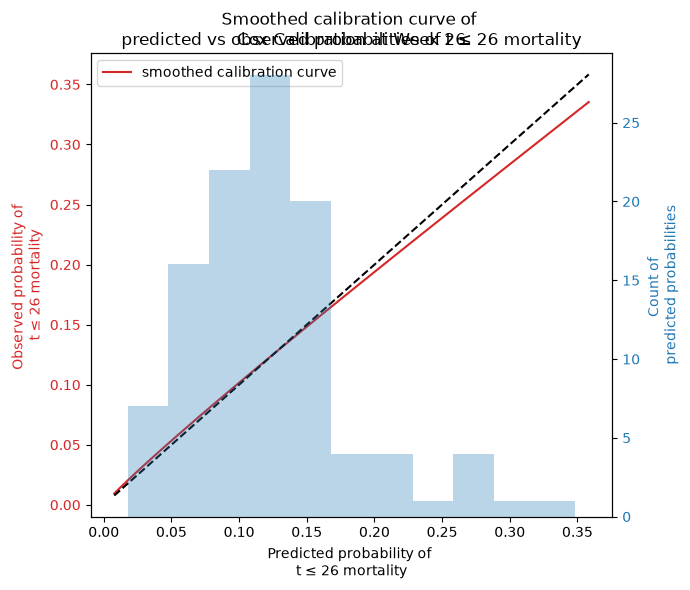

Cox calibration ICI: 0.002922621980401011
Cox calibration E50: 0.0021399586733866216


In [34]:
plt.figure(figsize=(7, 6))

(
    _,
    cox_calibration_ici,
    cox_calibration_e50
) = survival_probability_calibration(
    cox_model,
    test_df,
    t0=CALIBRATION_WEEK
)

plt.title(
    f"Cox Calibration at Week "
    f"{CALIBRATION_WEEK}"
)

plt.show()

print(
    "Cox calibration ICI:",
    cox_calibration_ici
)

print(
    "Cox calibration E50:",
    cox_calibration_e50
)

ICI =  0.017552734071243952
E50 =  0.01861095995303025


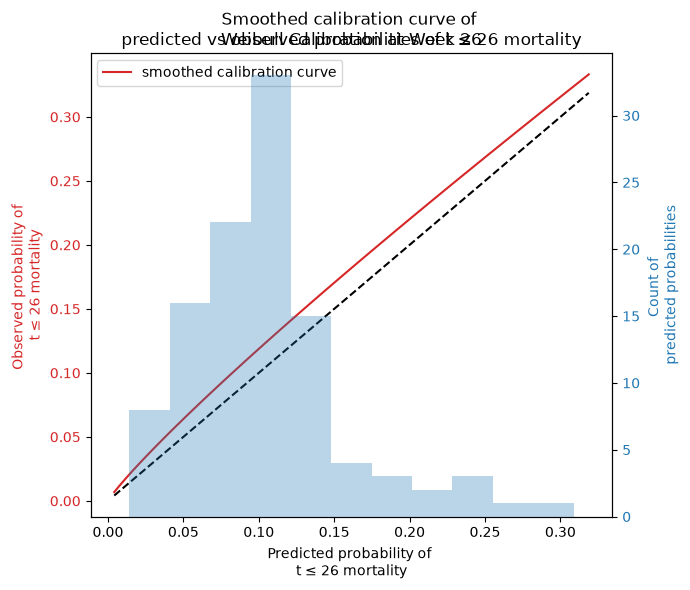

Weibull calibration ICI: 0.017552734071243952
Weibull calibration E50: 0.01861095995303025


In [35]:
plt.figure(figsize=(7, 6))

(
    _,
    weibull_calibration_ici,
    weibull_calibration_e50
) = survival_probability_calibration(
    weibull_model,
    test_df,
    t0=CALIBRATION_WEEK
)

plt.title(
    f"Weibull Calibration at Week "
    f"{CALIBRATION_WEEK}"
)

plt.show()

print(
    "Weibull calibration ICI:",
    weibull_calibration_ici
)

print(
    "Weibull calibration E50:",
    weibull_calibration_e50
)

In [36]:
calibration_summary_df = pd.DataFrame([
    {
        "model": "Full Cox PH",
        "week": CALIBRATION_WEEK,
        "ICI": cox_calibration_ici,
        "E50": cox_calibration_e50
    },
    {
        "model": "Weibull AFT",
        "week": CALIBRATION_WEEK,
        "ICI":
            weibull_calibration_ici,
        "E50":
            weibull_calibration_e50
    }
])

calibration_summary_df

,model,week,ICI,E50
0,Full Cox PH,26,0.002923,0.002140
1,Weibull AFT,26,0.017553,0.018611


## Probability-calibration 

At Week 26, calibration results were:

| Model | ICI | E50 |
|---|---:|---:|
| Full Cox PH | 0.0029 | 0.0021 |
| Weibull AFT | 0.0176 | 0.0186 |

Lower values indicate smaller differences between predicted and observed event probabilities.

The Cox model produced extremely strong 26-week calibration. Its smoothed calibration curve remained very close to the ideal diagonal across most of the prediction range.

The Weibull model also showed reasonably good calibration, but its error measures were approximately six to nine times larger than those of Cox. Its curve generally lay above the ideal line, suggesting modest underestimation of observed 26-week event probability.

Cox and Weibull had almost identical C-indices but noticeably different calibration. This demonstrates that discrimination and calibration measure separate model properties:

- concordance evaluates ranking
- calibration evaluates probability accuracy

In [37]:
cox_model.check_assumptions(
    train_df,
    p_value_threshold=0.05,
    show_plots=False
)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'age' failed the non-proportional test: p-value is 0.0088.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'work_experience' failed the non-proportional test: p-value is 0.0015.

   Advice: with so few unique values (only 2), you can include `strata=['work_experience', ...]` in
the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines

[]

## Proportional-hazards assumption 

The proportional-hazards diagnostic flagged two predictors:

- Age: `p = 0.0088`
- Work experience: `p = 0.0015`

This suggests that their estimated hazard relationships may not remain constant throughout follow-up.

For age, the issue could also reflect an incorrect linear functional form. The relationship between age and risk may be nonlinear rather than a constant effect per additional year.

For work experience, the binary groups may have hazard curves whose relative separation changes over time.

Possible responses include:

- adding nonlinear age terms or splines
- adding interactions with time
- stratifying by work experience
- fitting a model with time-varying coefficients
- relying on an alternative AFT formulation

The diagnostic does not automatically invalidate every Cox result, but it means that coefficient interpretations and predictions should be treated cautiously.

In [38]:
risk_order = np.argsort(
    cox_test_risk
)

selected_positions = [
    risk_order[
        int(0.10 * len(risk_order))
    ],
    risk_order[
        int(0.50 * len(risk_order))
    ],
    risk_order[
        int(0.90 * len(risk_order))
    ]
]

selected_profiles = (
    test_df.iloc[selected_positions]
    .copy()
)

selected_profiles[
    "risk_group"
] = [
    "Lower predicted risk",
    "Middle predicted risk",
    "Higher predicted risk"
]

selected_profiles[
    feature_columns
    + [
        duration_column,
        event_column,
        "risk_group"
    ]
]

,financial_aid,age,work_experience,married,parole,prior_convictions,duration_weeks,event_observed,risk_group
14,0,25,1,1,1,0,52,0,Lower predicted risk
49,1,25,1,0,1,5,52,0,Middle predicted risk
37,0,22,0,0,1,5,52,0,Higher predicted risk


In [39]:
selected_survival_curves = (
    cox_model.predict_survival_function(
        selected_profiles[
            feature_columns
        ]
    )
)

selected_survival_curves.columns = (
    selected_profiles[
        "risk_group"
    ].tolist()
)

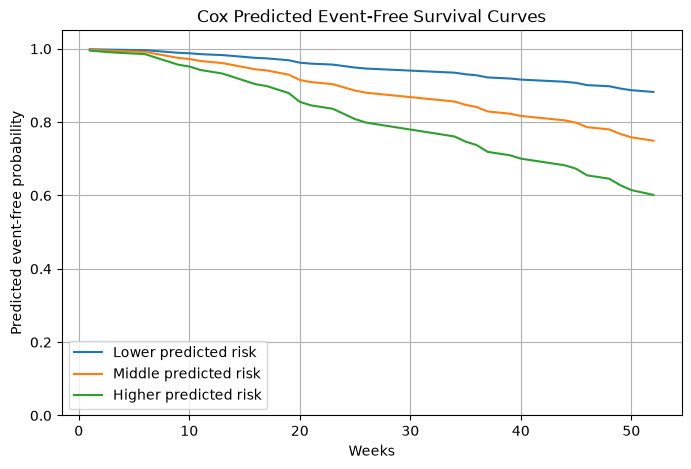

In [40]:
plt.figure(figsize=(8, 5))

for column in (
    selected_survival_curves.columns
):
    plt.plot(
        selected_survival_curves.index,
        selected_survival_curves[
            column
        ],
        label=column
    )

plt.title("Cox Predicted Event-Free Survival Curves")
plt.xlabel("Weeks")
plt.ylabel("Predicted event-free probability")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

## Individual survival-curves 

The selected lower-, middle-, and higher-risk profiles produced clearly separated predicted survival curves.

By Week 52, their approximate predicted event-free probabilities were:

- Lower predicted risk: 0.88
- Middle predicted risk: 0.75
- Higher predicted risk: 0.60

The lower-risk profile contained:

- Age 25
- Work experience
- Married
- No prior convictions

The higher-risk profile contained:

- Age 22
- No work experience
- Not married
- Five prior convictions

All three selected individuals were censored at Week 52, yet the model produced different probability trajectories based on their predictor profiles.

This illustrates an important feature of survival analysis: a censored outcome does not force every censored individual to receive the same predicted risk.

Unlike a binary classifier, the model generated a complete event-free probability curve for every week of follow-up.

In [41]:
cox_survival_at_26 = (
    cox_model.predict_survival_function(
        test_df[feature_columns],
        times=[CALIBRATION_WEEK]
    )
    .T
    .iloc[:, 0]
    .to_numpy()
)

weibull_survival_at_26 = (
    weibull_model.predict_survival_function(
        test_df[feature_columns],
        times=[CALIBRATION_WEEK]
    )
    .T
    .iloc[:, 0]
    .to_numpy()
)

In [42]:
prediction_df = test_df[
    [
        duration_column,
        event_column
    ]
].copy()

prediction_df[
    "cox_relative_risk"
] = cox_test_risk

prediction_df[
    "cox_event_probability_week_26"
] = (
    1 - cox_survival_at_26
)

prediction_df[
    "weibull_event_probability_week_26"
] = (
    1 - weibull_survival_at_26
)

prediction_df[
    "weibull_predicted_median_duration"
] = weibull_predicted_median

prediction_df.sort_values(
    "cox_relative_risk",
    ascending=False
).head(15)

,duration_weeks,event_observed,cox_relative_risk,cox_event_probability_week_26,weibull_event_probability_week_26,weibull_predicted_median_duration
24,33,1,3.507683,0.348362,0.308792,40.317022
92,17,1,2.969313,0.304089,0.268611,45.262226
9,52,0,2.723975,0.282929,0.249088,48.123421
6,8,1,2.715718,0.282205,0.248311,48.244809
51,52,0,2.505217,0.263518,0.229859,51.323751
20,52,0,2.459600,0.259405,0.227253,51.791558
33,48,1,2.331663,0.247746,0.215134,54.087686
44,52,0,2.010399,0.217653,0.187686,60.173501
18,17,1,2.005336,0.217169,0.188436,59.987941
69,52,0,1.866421,0.203779,0.176574,63.075523


## Individual-predictions 

The highest Cox-risk observations generally also received:

- larger predicted 26-week event probabilities
- shorter Weibull predicted median durations

The highest-ranked observation had:

- Cox relative risk: 3.5077
- Cox 26-week event probability: 0.3484
- Weibull 26-week event probability: 0.3088
- Weibull median duration: 40.32 weeks
- Observed event at Week 33

The second-highest observation experienced an event at Week 17.

However, several highly ranked observations were censored at Week 52. This does not prove that their risk predictions were incorrect because their eventual outcomes after follow-up were unknown.

Likewise, some observed events occurred among moderately ranked cases. Survival predictions describe probabilities and relative risk, not deterministic outcomes.

Several Weibull median predictions exceeded 52 weeks. These values represent model extrapolation beyond the observed follow-up window and should be interpreted cautiously.

In [43]:
ranking_correlation = (
    pd.Series(
        cox_test_risk
    )
    .corr(
        pd.Series(
            -weibull_predicted_median
        ),
        method="spearman"
    )
)

print(
    "Spearman risk-ranking correlation:",
    round(ranking_correlation, 4)
)

Spearman risk-ranking correlation: 0.9995


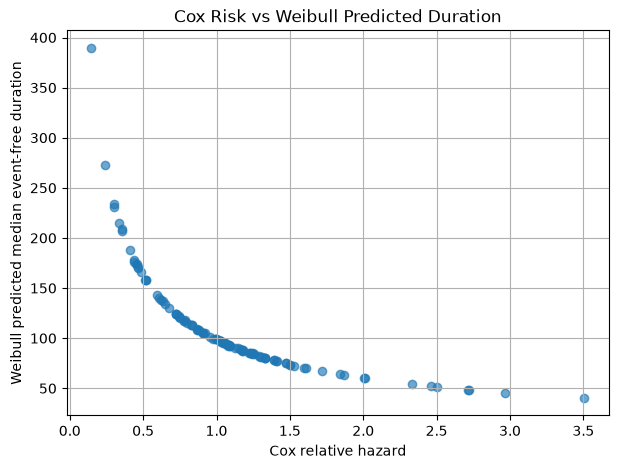

In [44]:
plt.figure(figsize=(7, 5))

plt.scatter(
    cox_test_risk,
    weibull_predicted_median,
    alpha=0.65
)

plt.title("Cox Risk vs Weibull Predicted Duration")
plt.xlabel("Cox relative hazard")
plt.ylabel("Weibull predicted median event-free duration")
plt.grid(True)
plt.show()

## Model-agreement 

The Spearman correlation between:

- Cox relative hazard
- negative Weibull predicted median duration

was:

`0.9995`

This indicates almost perfect agreement in how the two full models ranked test observations.

The positive value occurs because the Weibull duration was multiplied by negative one before calculating the correlation. Higher Cox risk and shorter Weibull duration therefore both corresponded to larger risk scores.

Using the unmodified Weibull median duration would produce an approximately:

`-0.9995`

correlation with Cox risk.

Despite imposing different modelling assumptions, Cox and Weibull effectively ordered individuals from lower to higher predicted risk in the same way. Their main differences appeared in probability calibration and the interpretation of coefficients rather than ranking.